
# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use('ggplot')
sns.set_style('whitegrid')

#### This project uses Pandas for data manipulation, NumPy for numerical operations,and Matplotlib & Seaborn for creating visualizations.

# Load Dataset


In [7]:
df=pd.read_csv('Unemployment in India.csv')

#### The unemployment dataset is loaded into a Pandas DataFrame.This allows us to perform analysis and visualization efficiently.

# Display first five rows

In [8]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762,44.68,Rural


### head command shows first five rows from the dataset

# Check dataset information

In [12]:
#Shape of Dataset
(df.shape)

(740, 7)

In [14]:
#Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    int64  
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(2), int64(1), object(4)
memory usage: 40.6+ KB


In [15]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


#### Understanding the structure of the dataset helps identify the number of rows, columns, data types, and overall data quality.

# Check Missing Values

In [16]:
df.isnull().sum()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64

####  There is No missing values in this dataset.


# convert date column

In [19]:
df['Date']=pd.to_datetime(df['Date'])

C:\Users\archa\AppData\Local\Temp\ipykernel_14760\3023999556.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date']=pd.to_datetime(df['Date'])


#### The date column is converted into datetime format, allowing time-based analysis and feature extraction.

In [20]:
df.dtypes

Region                                         object
Date                                   datetime64[ns]
Frequency                                      object
Estimated Unemployment Rate                   float64
Estimated Employed                              int64
Estimated Labour Participation Rate           float64
Area                                           object
dtype: object

# Extract Year and Month

In [21]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()

df[['Date','Year','Month']].head()

,Date,Year,Month
0,2019-05-31,2019,May
1,2019-06-30,2019,June
2,2019-07-31,2019,July
3,2019-08-31,2019,August
4,2019-09-30,2019,September


#### Year and month are extracted from the date column to analyze unemployment trends over time.

# Basic Statistics

In [22]:
# average unemployment rate
avg_rate = df['Estimated Unemployment Rate'].mean()
print('Average Unemployment Rate:', round(avg_rate,2))

Average Unemployment Rate: 11.79


In [23]:
# minimum and maximum
print('Minimum Rate:', df['Estimated Unemployment Rate'].min())
print('Maximum Rate:', df['Estimated Unemployment Rate'].max())

Minimum Rate: 0.0
Maximum Rate: 76.74


#### Descriptive statistics provide an overview of the dataset, including mean, minimum, maximum, and standard deviation.

# Distribution of Unemployment Rate

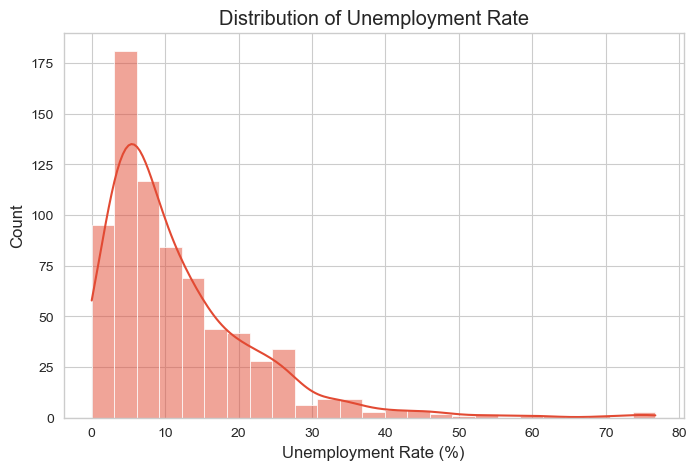

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df['Estimated Unemployment Rate'], bins=25, kde=True)
plt.title('Distribution of Unemployment Rate')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Count')
plt.show()

#### This chart shows how unemployment rates are distributed across the dataset, with most values concentrated within a specific range.

# Unemployment Trend Over Time

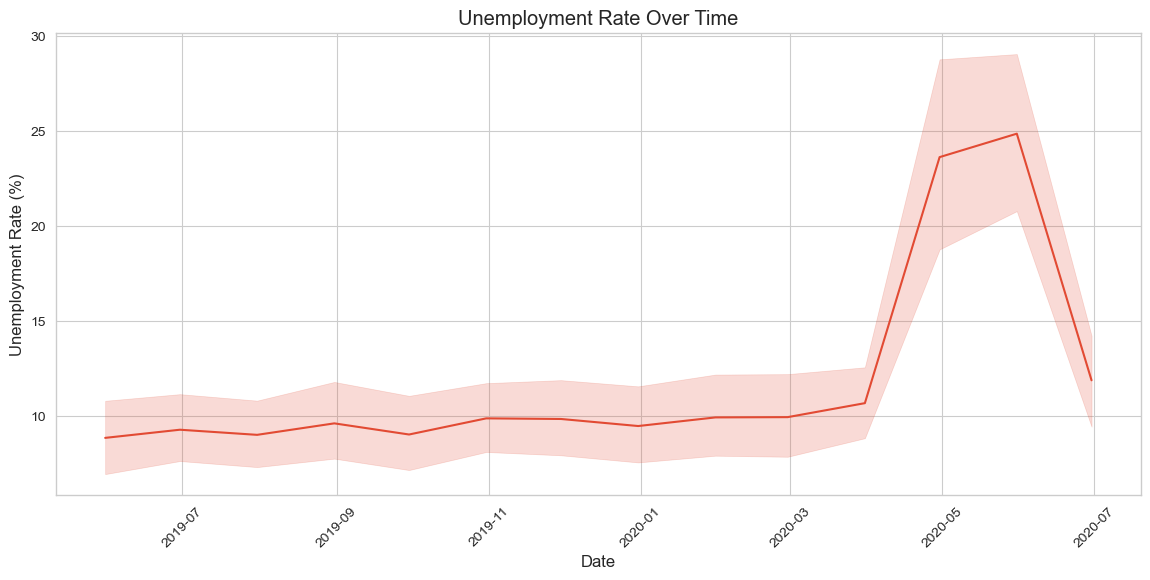

In [25]:
plt.figure(figsize=(14,6))
sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate')
plt.title('Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.show()

#### This chart shows the COVID-19 spike in 2020.

# Average Unemployment by Year

In [26]:
yearly = df.groupby('Year')['Estimated Unemployment Rate'].mean()
print(yearly)

Year
2019     9.399047
2020    15.101581
Name: Estimated Unemployment Rate, dtype: float64


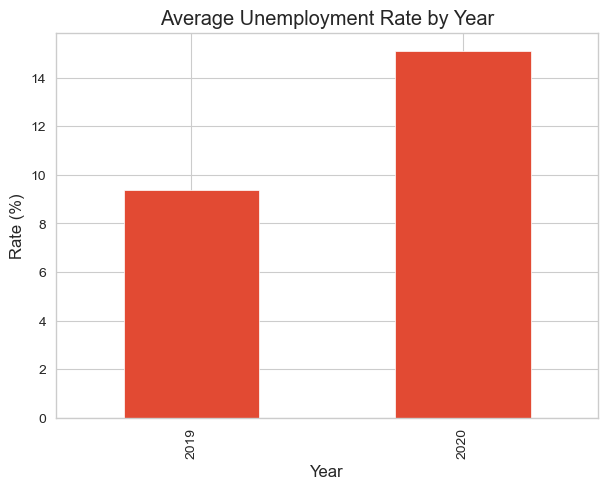

In [27]:
yearly.plot(kind='bar', figsize=(7,5))
plt.title('Average Unemployment Rate by Year')
plt.ylabel('Rate (%)')
plt.show()

### This chart compares the average unemployment rate across different years and highlights yearly changes.

# State-wise Analysis

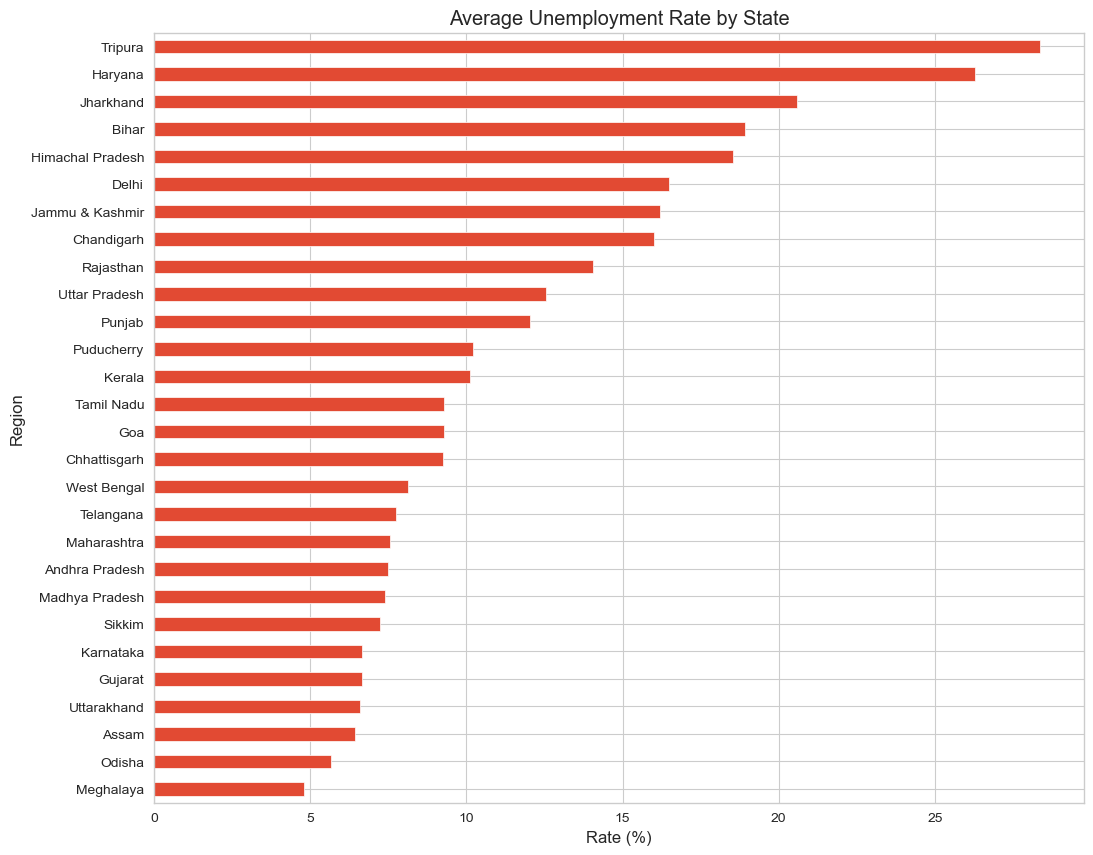

In [28]:
state_avg = df.groupby('Region')['Estimated Unemployment Rate'].mean().sort_values()

plt.figure(figsize=(12,10))
state_avg.plot(kind='barh')
plt.title('Average Unemployment Rate by State')
plt.xlabel('Rate (%)')
plt.show()

### This analysis compares unemployment rates across states to identify regions with higher unemployment.
### Tripura is the highest unemployment rate across states

# Urban vs Rural Comparison

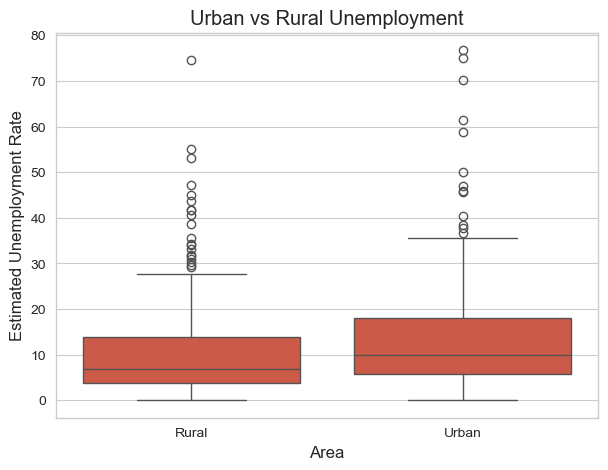

In [29]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Area', y='Estimated Unemployment Rate')
plt.title('Urban vs Rural Unemployment')
plt.show()

### Comparing urban and rural unemployment helps identify differences between geographical areas.

# Monthly / Seasonal Trend

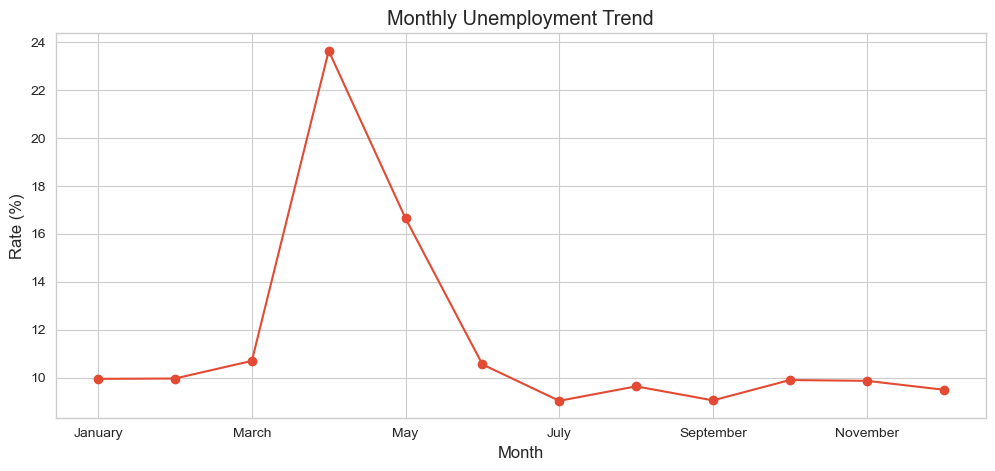

In [30]:
month_avg = df.groupby('Month')['Estimated Unemployment Rate'].mean()


month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

month_avg = month_avg.reindex(month_order)

plt.figure(figsize=(12,5))
month_avg.plot(marker='o')
plt.title('Monthly Unemployment Trend')
plt.ylabel('Rate (%)')
plt.show()

### April month is the highest unemployed trend

# Heatmap (State vs Year)

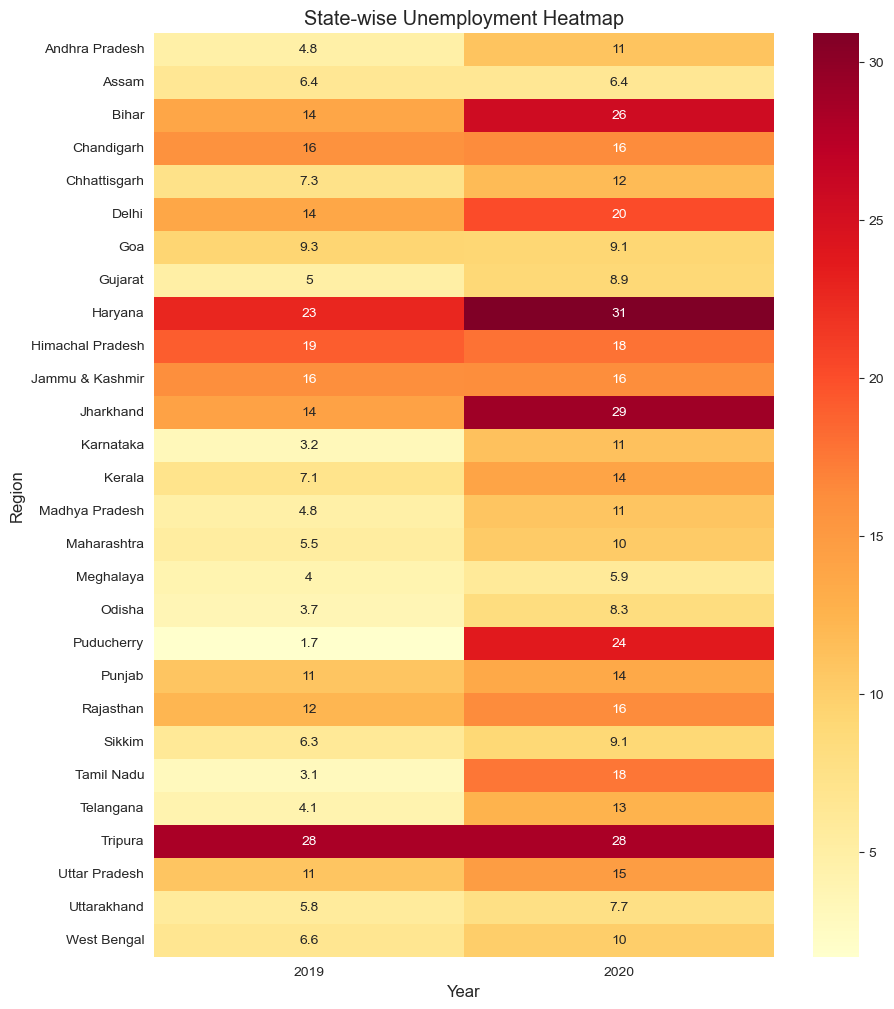

In [31]:
pivot = df.pivot_table( values='Estimated Unemployment Rate', index='Region', columns='Year')

plt.figure(figsize=(10,12))
sns.heatmap(pivot, annot=True, cmap='YlOrRd')
plt.title('State-wise Unemployment Heatmap')
plt.show()

### A heatmap provides a visual comparison of unemployment across different states and years.

# COVID-19 Impact Analysis

In [32]:
before_covid = df[df['Date'] < '2020-03-01']
after_covid = df[df['Date'] >= '2020-03-01']

before_avg = before_covid['Estimated Unemployment Rate'].mean()
after_avg = after_covid['Estimated Unemployment Rate'].mean()

print('Before Covid:', round(before_avg,2))
print('During Covid:', round(after_avg,2))

Before Covid: 9.51
During Covid: 17.77


### The dataset is divided into pre-COVID and during-COVID periods to measure the impact of the pandemic on unemployment.
### Before covid - 9.51 
### After covid - 17.77


# Visualize COVID Impact

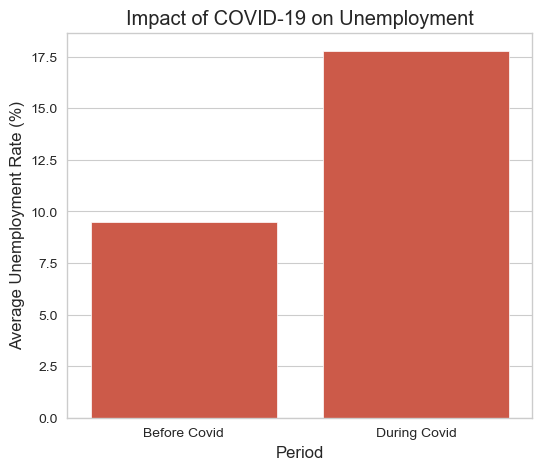

In [33]:
covid = pd.DataFrame({
    'Period':['Before Covid','During Covid'],
    'Average Rate':[before_avg, after_avg]
})

plt.figure(figsize=(6,5))
sns.barplot(data=covid, x='Period', y='Average Rate')
plt.title('Impact of COVID-19 on Unemployment')
plt.ylabel('Average Unemployment Rate (%)')
plt.show()

### A bar chart compares average unemployment rates before and during the pandemic.

### Before Covid ≈ 9–10%

### During Covid ≈ 12–14% (varies by dataset)

# Correlation Analysis

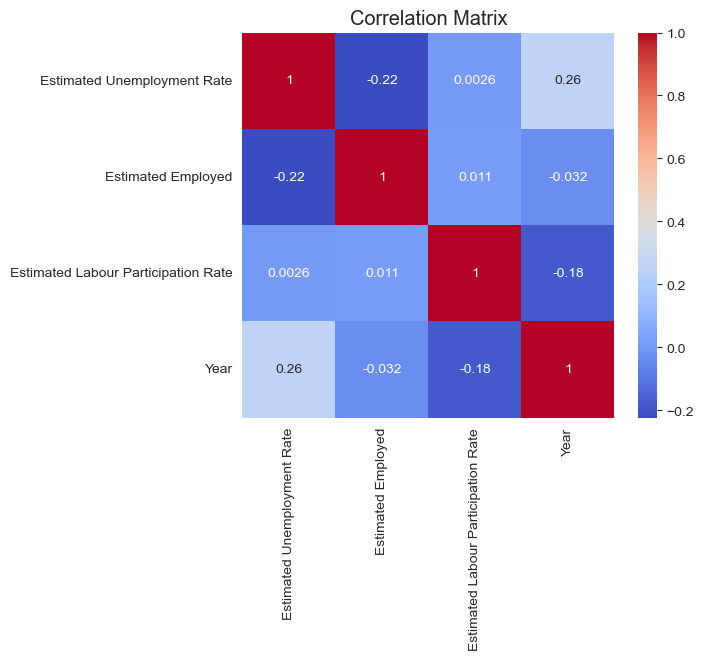

In [34]:
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### The correlation matrix shows relationships between numerical variables in the dataset.

# Save Cleaned Dataset

In [35]:
df.to_csv('cleaned_unemployment.csv', index=False)
print('Cleaned dataset saved successfully.')

Cleaned dataset saved successfully.


### The cleaned dataset is exported as a CSV file for future analysis and reporting.

# Final Insights

In [36]:
print('FINAL INSIGHTS')
print('-'*40)
print(f'Overall Average Unemployment Rate: {avg_rate:.2f}%')
print(f'Before Covid: {before_avg:.2f}%')
print(f'During Covid: {after_avg:.2f}%')

if after_avg > before_avg:
    print('Unemployment increased significantly during Covid-19.')
else:
    print('No significant increase observed.')

highest_state = state_avg.idxmax()
lowest_state = state_avg.idxmin()

print(f'Highest unemployment state: {highest_state}')
print(f'Lowest unemployment state: {lowest_state}')

FINAL INSIGHTS
----------------------------------------
Overall Average Unemployment Rate: 11.79%
Before Covid: 9.51%
During Covid: 17.77%
Unemployment increased significantly during Covid-19.
Highest unemployment state: Tripura
Lowest unemployment state: Meghalaya


# Overall Average Unemployment Rate: 11.79%
# Before Covid: 9.51%
# During Covid: 17.77%
# Unemployment increased significantly during Covid-19.
# Highest unemployment state: Tripura
# Lowest unemployment state: Meghalaya

# Conclusion

# Using Python, unemployment data was cleaned, explored, and visualized to study employment trends in India. The analysis showed a sharp rise in unemployment during the COVID-19 pandemic, particularly in urban regions. Several states experienced consistently higher unemployment rates than the national average. Monthly analysis revealed seasonal fluctuations, while heatmap visualization highlighted regional disparities. The findings suggest that targeted employment programs, skill development initiatives, and economic support measures are necessary to reduce unemployment during periods of crisis.